# Projeto de Disciplina de Processamento de Linguagem Natural com Python

Bem-vindo ao projeto de disciplina de **Processamento de Linguagem Natural com Python**. Ao longo das últimas aulas vimos uma série de aplicações que nos deram a amplitude de possibilidades em trabalhar com textos. Para tal, usamos diversas bibliotecas, onde as que mais se destacaram foram NLTK, SPACY e GENSIM.

Esse notebook servirá de guia para a execução de uma análise de tópicos completa, usando o algoritmo de LDA e recursos para interpretação dos resultados. Utilizaremos notícias da seção "Mercado" extraídas da Folha de S. Paulo no ano de 2016.  Complete a análise com os códigos que achar pertinente e responda as questões presentes no Moodle. Boa sorte!

## O Notebook

Nesse notebook, você será guiado pela análise de **Extração de Tópicos**. As seguintes tarefas serão realizadas


1.   Download dos dados provenientes do kaggle
2.   Seleção dos dados relevantes para a nossa análise
3.   Instalação das principais ferramentas e importação de módulos
4.   Pré-processamento usando NLTK
5.   Pré-processamento usando Spacy
6.   Análise de tópicos usando LDA
7.   Análise de NER usando Spacy
8.   Visualização dos tópicos usando tokens e entidades.



## Instruções para baixar os dados

Para baixar os dados será necessário o uso do gerenciador de downloads da Kaggle. A Kaggle, uma subsidiária do grupo Alphabet (Google), é uma comunidade on-line de cientistas de dados e profissionais de aprendizado de máquina.

Para utilizar o gerenciador, será necessário criar uma conta no site Kaggle.com.
Com a conta criada, obtenha um token de acesso, no formato kaggle.json

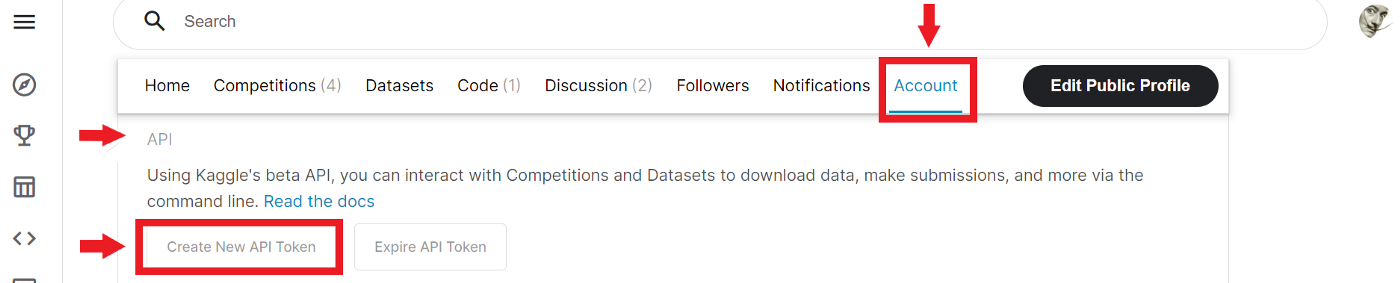

Em posse do token (baixe para seu computador), execute a células da próxima seção para acessar os dados de interesse e baixá-los.

# Baixe os dados

Instale o gerenciador kaggle no ambiente do Colab e faça o upload do arquivo kaggle.json

In [1]:
#!pip install -q kaggle
#!rm -rf kaggle.json
#from google.colab import files

#files.upload()


Crie a pasta .kaggle

In [2]:
#!rm -rf .kaggle
#!mkdir .kaggle
#!cp kaggle.json .kaggle/
#!chmod 600 .kaggle/kaggle.json

Baixe o dataset

In [3]:
#!kaggle datasets download --force -d marlesson/news-of-the-site-folhauol

## Criar o DataFrame com os dados lidos diretamente da plataforma Kaggle

In [4]:
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

#ler local
df = pd.read_csv("articles.csv")

/home/leo/.pyenv/versions/nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df.head()

,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


# Atualizar o SPACY e  instalar os modelos pt_core_news_lg

In [6]:
# Escreva seu código aqui
# !pip install -U spacy
# !python -m spacy download pt_core_news_lg
#

import spacy
from spacy.lang.pt.stop_words import STOP_WORDS

nlp = spacy.load("pt_core_news_lg")

In [7]:
print(STOP_WORDS)

{'máximo', 'ter', 'cá', 'tempo', 'terceiro', 'dos', 'diante', 'fim', 'pode', 'desta', 'deve', 'qualquer', 'cuja', 'quieto', 'teve', 'bastante', 'partir', 'estás', 'certeza', 'este', 'minhas', 'ponto', 'devem', 'valor', 'pegar', 'possível', 'usa', 'ali', 'ligado', 'alguns', 'iniciar', 'próxima', 'pontos', 'sexta', 'treze', 'era', 'muito', 'baixo', 'tendes', 'adeus', 'local', 'números', 'daquele', 'tivemos', 'vossa', 'porquê', 'estas', 'tarde', 'nuns', 'disso', 'nos', 'tentar', 'ou', 'posso', 'vão', 'aqui', 'seus', 'somente', 'fazem', 'for', 'comprido', 'o', 'sob', 'apontar', 'vez', 'sexto', 'questão', 'maioria', 'poderá', 'quanto', 'sois', 'mês', 'numa', 'zero', 'nossa', 'estou', 'sistema', 'temos', 'tiveram', 'ambas', 'último', 'nas', 'lugar', 'dizer', 'nenhuma', 'esteve', 'algumas', 'na', 'vós', 'e', 'vossos', 'fará', 'qual', 'está', 'vezes', 'conhecida', 'seria', 'pois', 'quando', 'em', 'sem', 'dezanove', 'obrigado', 'cedo', 'conhecido', 'dá', 'têm', 'vindo', 'porém', 'próprio', 'tan

## Instalar os datasets `stopwords`, `punkt` e `rslp` do nltk

In [8]:
#!pip install -U nltk
#

import nltk

# Escreva seu código aqui
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("rslp")

[nltk_data] Downloading package stopwords to /home/leo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/leo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package rslp to /home/leo/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

## Carregar os módulos usados ao longo desse notebook

In [9]:
#!pip install pyldavis &> /dev/null

#import warnings
#warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
import numpy as np

from wordcloud import WordCloud

import seaborn as sns
import matplotlib.pyplot as plt
from itertools import chain

from typing import List, Set, Any


SEED = 123

# Filtrando os dados para utilizar apenas as notícias do ano de 2016 e da categoria "Mercado"

Filtre os dados do DataFrame df e crie um DataFrame news_2016 que contenha apenas notícias de **2016** e da categoria **mercado**.

In [10]:
df['date'] = pd.to_datetime(df.date)
# Create a dataframe named news_2016
news_2016 = df.loc[(df['date'].dt.year == 2016) & (df['category'] == 'mercado')]
news_2016

,title,text,date,category,subcategory,link
34207,Fazendeira cria própria rede de banda larga e ...,"""Sou apenas a mulher de um fazendeiro"", diz Ch...",2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...
34238,Alteração na cobrança do ICMS eleva conta de c...,A conta do celular pós-pago ou controle ficará...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...
34245,Ajustes sobre servidores públicos emperram nos...,A maior parte dos projetos de ajuste das conta...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...
34248,Inventor da internet das coisas ataca mitos so...,Desde as primeiras décadas do século 19 se diz...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...
34249,Livro analisa empresas de crescimento exponenc...,O Cifras & Letras seleciona semanalmente lança...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...
...,...,...,...,...,...,...
94280,Previsões para economia dependem de rumos do g...,"Para o economista Rodolfo Margato, do banco Sa...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...
94295,Repelentes e água de coco lideram a lista de s...,"Conveniência, saúde, boa forma e prazer. As te...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...
94301,Renda em queda leva mais pessoas às filas de e...,"Com o rendimento em queda, mais pessoas são fo...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...
94310,"Brasil pode perder até 2,2 milhões de vagas fo...","O Brasil pode perder até 2,2 milhões de vagas ...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...


## NLTK Tokenizer and Stemmer

Crie uma coluna no dataframe `news_2016` contendo os tokens para cada um dos textos. Os tokens devem estar representados pelo radical das palavras (stem).
Para tal, complete o conteúdo da função `tokenize`.

In [11]:
NEW_STOP_WORDS = STOP_WORDS.union(nltk.corpus.stopwords.words('portuguese'))

def tokenize(text: str) -> List:
  """
  Function for tokenizing using `nltk.tokenize.word_tokenize`

  Returns:
    - A list of stemmed tokens (`nltk.stem.RSLPStemmer`)
    IMPORTANT: Only tokens with alphabetic
               characters will be returned.
  """
  # Tokenize
  tokens = nltk.tokenize.word_tokenize(text.lower(), language='portuguese')

  # Remove stop words
  tokens = [token for token in tokens if token not in NEW_STOP_WORDS]

  # Remove non-alphabetic tokens
  tokens = [token for token in tokens if token.isalpha()]

  # Stem
  stemmer = nltk.stem.RSLPStemmer()
  tokens = [stemmer.stem(token) for token in tokens]

  return tokens

news_2016.loc[:, 'nltk_tokens'] = news_2016.text.progress_map(tokenize)
news_2016

100%|██████████| 7943/7943 [00:44<00:00, 178.02it/s] 
/tmp/ipykernel_1535/3175441244.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_2016.loc[:, 'nltk_tokens'] = news_2016.text.progress_map(tokenize)


,title,text,date,category,subcategory,link,nltk_tokens
34207,Fazendeira cria própria rede de banda larga e ...,"""Sou apenas a mulher de um fazendeiro"", diz Ch...",2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[mulh, fazend, christin, cond, modést, mor, co..."
34238,Alteração na cobrança do ICMS eleva conta de c...,A conta do celular pós-pago ou controle ficará...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[cont, celul, control, fic, car, decis, stf, o..."
34245,Ajustes sobre servidores públicos emperram nos...,A maior parte dos projetos de ajuste das conta...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[projet, ajust, cont, públic, aprov, est, pi, ..."
34248,Inventor da internet das coisas ataca mitos so...,Desde as primeiras décadas do século 19 se diz...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[prim, déc, sécul, diz, not, óper, sinfon, bro..."
34249,Livro analisa empresas de crescimento exponenc...,O Cifras & Letras seleciona semanalmente lança...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[cifr, letr, selec, seman, lanç, negóci, econo..."
...,...,...,...,...,...,...,...
94280,Previsões para economia dependem de rumos do g...,"Para o economista Rodolfo Margato, do banco Sa...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[econom, rodolf, margat, banc, santand, econom..."
94295,Repelentes e água de coco lideram a lista de s...,"Conveniência, saúde, boa forma e prazer. As te...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[conveni, saúd, praz, tend, consum, marc, ano,..."
94301,Renda em queda leva mais pessoas às filas de e...,"Com o rendimento em queda, mais pessoas são fo...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[rend, qued, pesso, forç, busc, fil, empreg, c..."
94310,"Brasil pode perder até 2,2 milhões de vagas fo...","O Brasil pode perder até 2,2 milhões de vagas ...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[brasil, perd, milhã, vag, cart, assin, ano, c..."


## Criar uma documento SPACY para cada texto do dataset

Crie uma coluna `spacy_doc` que contenha os objetos spacy para cada texto do dataset de interesse. Para tal, carregue os modelos `pt_core_news_lg` e aplique em todos os textos (pode demorar alguns minutos...)

In [12]:
# Escreva seu código aqui
# ...

news_2016.loc[:, "spacy_doc"] = news_2016.progress_apply(lambda x: nlp((x.text.lower())), axis=1)

100%|██████████| 7943/7943 [06:07<00:00, 21.60it/s] 
/tmp/ipykernel_1535/888212496.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_2016.loc[:, "spacy_doc"] = news_2016.progress_apply(lambda x: nlp((x.text.lower())), axis=1)


In [13]:
news_2016.head()

,title,text,date,category,subcategory,link,nltk_tokens,spacy_doc
34207,Fazendeira cria própria rede de banda larga e ...,"""Sou apenas a mulher de um fazendeiro"", diz Ch...",2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[mulh, fazend, christin, cond, modést, mor, co...","("", sou, apenas, a, mulher, de, um, fazendeiro..."
34238,Alteração na cobrança do ICMS eleva conta de c...,A conta do celular pós-pago ou controle ficará...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[cont, celul, control, fic, car, decis, stf, o...","(a, conta, do, celular, pós-pago, ou, controle..."
34245,Ajustes sobre servidores públicos emperram nos...,A maior parte dos projetos de ajuste das conta...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[projet, ajust, cont, públic, aprov, est, pi, ...","(a, maior, parte, dos, projetos, de, ajuste, d..."
34248,Inventor da internet das coisas ataca mitos so...,Desde as primeiras décadas do século 19 se diz...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[prim, déc, sécul, diz, not, óper, sinfon, bro...","(desde, as, primeiras, décadas, do, século, 19..."
34249,Livro analisa empresas de crescimento exponenc...,O Cifras & Letras seleciona semanalmente lança...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[cifr, letr, selec, seman, lanç, negóci, econo...","(o, cifras, &, letras, seleciona, semanalmente..."


## Realize a Lematização usando SPACY

O modelo NLP do spacy oferece a possiblidade de lematizar textos em português (o que não acontece com a biblioteca NLTK). Iremos criar uma lista de tokens
lematizados para cada texto do nosso dataset. Para tal, iremos retirar as
stopwords, usando uma função que junta stopwords provenientes do NLTK e do Spacy. Essa lista completa, é retornada pela função stopwords (e você não precisa mexer).

Já a função filter retorna True caso o token seja composto por caracters alfabéticos, não estiver dentro da lista de stopwords e o lemma resultante não estiver contido na lista `o", "em", "em o", "em a" e "ano"`.

Crie uma coluna chamada `spacy_lemma` para armazenar o resultado desse pré-processamento.

In [ ]:
def stopwords() -> Set:
    """
    Return complete list of stopwords
    """
    return set(list(nltk.corpus.stopwords.words("portuguese")) + list(STOP_WORDS))

complete_stopwords = stopwords()

def filter(w: spacy.lang.pt.Portuguese) -> bool:
    """
    Filter stopwords and undesired tokens
    """
    # Escreva seu código aqui

    return (
        w.is_alpha and
        w.lemma_.lower() not in complete_stopwords and
        w.lemma_.lower() not in ["o", "em", "em o", "em a", "ano", "de o", "em", "para", "por o", "a o", "em este"] #added more words
    )

def lemma(doc: spacy.lang.pt.Portuguese) -> List[str]:
    """
    Apply spacy lemmatization on the tokens of a text

    Returns:
       - a list representing the standardized (with lemmatisation) vocabulary
    """
    # Escreva seu código aqui
    return [token.lemma_.lower() for token in doc if filter(token)]


news_2016.loc[:, 'spacy_lemma'] = news_2016.spacy_doc.progress_map(lemma)

  0%|          | 0/7943 [00:00<?, ?it/s]

100%|██████████| 7943/7943 [00:06<00:00, 1180.12it/s]


## Reconhecimento de entidades nomeadas

Crie uma coluna `spacy_ner` que armazene todas as organizações (APENAS organizações) que estão contidas no texto.

In [59]:
def NER(doc: spacy.lang.pt.Portuguese):
  """
  Return the list of organizations for a SPACY document
  """
  # Escreva seu código aqui
  return [ent.text for ent in doc.ents if ent.label_ == "ORG"]

news_2016.loc[:, 'spacy_ner'] = news_2016.spacy_doc.progress_map(NER)
news_2016

100%|██████████| 7943/7943 [00:00<00:00, 25539.44it/s]


,title,text,date,category,subcategory,link,nltk_tokens,spacy_doc,spacy_lemma,spacy_ner,tfidf,topic
34207,Fazendeira cria própria rede de banda larga e ...,"""Sou apenas a mulher de um fazendeiro"", diz Ch...",2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[mulh, fazend, christin, cond, modést, mor, co...","("", sou, apenas, a, mulher, de, um, fazendeiro...","[mulher, fazendeiro, christine, conder, modést...","[lune valley, bt, virgin]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2
34238,Alteração na cobrança do ICMS eleva conta de c...,A conta do celular pós-pago ou controle ficará...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[cont, celul, control, fic, car, decis, stf, o...","(a, conta, do, celular, pós-pago, ou, controle...","[conta, celular, controle, ficar, cara, decisã...","[stf, oi, tim, stf]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",8
34245,Ajustes sobre servidores públicos emperram nos...,A maior parte dos projetos de ajuste das conta...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[projet, ajust, cont, públic, aprov, est, pi, ...","(a, maior, parte, dos, projetos, de, ajuste, d...","[projeto, ajuste, conta, público, aprovar, mau...",[tv minas],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",8
34248,Inventor da internet das coisas ataca mitos so...,Desde as primeiras décadas do século 19 se diz...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[prim, déc, sécul, diz, not, óper, sinfon, bro...","(desde, as, primeiras, décadas, do, século, 19...","[década, século, nota, ópera, sinfonia, brotar...","[mit, apple]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2
34249,Livro analisa empresas de crescimento exponenc...,O Cifras & Letras seleciona semanalmente lança...,2016-12-31,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/12/1...,"[cifr, letr, selec, seman, lanç, negóci, econo...","(o, cifras, &, letras, seleciona, semanalmente...","[cifras, letra, selecionar, semanalmente, lanç...","[r$, r$ 69, amazon, benbella books, r$]","[0.0, 0.0, 0.04091155804271703, 0.0, 0.0, 0.0,...",2
...,...,...,...,...,...,...,...,...,...,...,...,...
94280,Previsões para economia dependem de rumos do g...,"Para o economista Rodolfo Margato, do banco Sa...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[econom, rodolf, margat, banc, santand, econom...","(para, o, economista, rodolfo, margato, ,, do,...","[economista, rodolfo, margato, banco, santande...","[fgv/, ibre]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2
94295,Repelentes e água de coco lideram a lista de s...,"Conveniência, saúde, boa forma e prazer. As te...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[conveni, saúd, praz, tend, consum, marc, ano,...","(conveniência, ,, saúde, ,, boa, forma, e, pra...","[conveniência, saúde, prazer, tendência, consu...","[nielsen, nielsen, nielsen, nielsen]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2
94301,Renda em queda leva mais pessoas às filas de e...,"Com o rendimento em queda, mais pessoas são fo...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[rend, qued, pesso, forç, busc, fil, empreg, c...","(com, o, rendimento, em, queda, ,, mais, pesso...","[rendimento, queda, pessoa, forçar, buscar, fi...","[lca, lca]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2
94310,"Brasil pode perder até 2,2 milhões de vagas fo...","O Brasil pode perder até 2,2 milhões de vagas ...",2016-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2016/01/1...,"[brasil, perd, milhã, vag, cart, assin, ano, c...","(o, brasil, pode, perder, até, 2,2, milhões, d...","[brasil, perder, milhão, vaga, carteira, assin...","[lca, pnad contínua, lca, pme, pme r$]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2


## Bag-of-Words

Crie uma coluna `tfidf` no dataframe `news_2016`. Use a coluna `spacy_lemma` como base para cálculo do TFIDF.
O número máximo de features que iremos considerar é 5000. E o token, tem que ter aparecido pelo menos 10 vezes (`min_df`) nos documentos.

In [60]:
class Vectorizer:
  def __init__(self, doc_tokens: List):
    self.doc_tokens = doc_tokens
    self.tfidf = None


  def vectorizer(self):
      """
      Convert a list of tokens to tfidf vector
      Returns the tfidf vector and attribute it to self.tfidf
      """
      # Escreva seu código aqui
      self.doc_tokens = [' '.join(tokens) for tokens in self.doc_tokens]
      self.tfidf = TfidfVectorizer(
         max_features=5000,
         min_df=10
      )
      self.tfidf.fit_transform(self.doc_tokens)
      return self.tfidf

  def __call__(self):
    if self.tfidf is None:
        self.vectorizer()
    return self.tfidf

doc_tokens = news_2016.spacy_lemma.values.tolist()
vectorizer = Vectorizer(doc_tokens)

def tokens2tfidf(tokens):
    tokens = ' '.join(tokens)
    array =  vectorizer().transform([tokens]).toarray()[0]
    return array


news_2016.loc[:, 'tfidf'] = news_2016.spacy_lemma.progress_map(tokens2tfidf)

100%|██████████| 7943/7943 [00:05<00:00, 1425.25it/s]


In [73]:
#count common words
from collections import Counter
tokens = [lemma for li in news_2016['spacy_lemma'] for lemma in li]
common = Counter(tokens).most_common(50)
for c in common:
    print(c)

('empresa', 12297)
('governo', 11000)
('bilhão', 9987)
('em este', 9933)
('mercado', 9039)
('banco', 8433)
('país', 8214)
('afirmar', 7330)
('brasil', 7060)
('outro', 6803)
('dever', 5959)
('presidente', 5869)
('milhão', 5838)
('queda', 5623)
('setor', 5045)
('juro', 5024)
('preço', 5012)
('acordo', 4681)
('ação', 4510)
('dia', 4505)
('economia', 4494)
('investimento', 4466)
('passado', 4435)
('companhia', 4390)
('público', 4359)
('pequeno', 4288)
('brasileiro', 4225)
('econômico', 4197)
('índice', 3935)
('venda', 3911)
('financeiro', 3899)
('medida', 3875)
('taxa', 3844)
('alta', 3800)
('petróleo', 3667)
('ficar', 3608)
('pessoa', 3575)
('dólar', 3558)
('federal', 3525)
('caso', 3479)
('central', 3421)
('dívida', 3309)
('aumento', 3297)
('receita', 3278)
('pagar', 3229)
('crescimento', 3229)
('inflação', 3199)
('proposta', 3143)
('serviço', 3135)
('projeto', 3126)


## Extração de Tópicos

Realize a extração de 9 tópicos usando a implementação do sklearn do algoritmo Latent Dirichlet Allocation. Como parâmetros, você irá usar o número máximo de iterações igual à 100 (pode demorar) e o `random_seed` igual a `SEED` que foi setado no início do notebook

In [62]:
N_TOKENS = 9

corpus = np.array(news_2016.tfidf.tolist())
#Escreva seu código aqui
lda = LDA(
    n_components=N_TOKENS,
    random_state=SEED,
    max_iter=100
)
lda.fit_transform(corpus)

array([[0.01068   , 0.01067216, 0.4946337 , ..., 0.01067859, 0.01066975,
        0.43065382],
       [0.01422505, 0.01421335, 0.27323015, ..., 0.61085511, 0.01421187,
        0.03061312],
       [0.0099847 , 0.00997883, 0.00998963, ..., 0.92013561, 0.00997849,
        0.00998205],
       ...,
       [0.04711154, 0.0138459 , 0.85585157, ..., 0.01387148, 0.01384542,
        0.0139376 ],
       [0.22106581, 0.00927152, 0.71400673, ..., 0.00927697, 0.00927062,
        0.0092938 ],
       [0.01097964, 0.01097739, 0.010987  , ..., 0.73916834, 0.01097536,
        0.01097954]], shape=(7943, 9))

### Atribua a cada text, um (e apenas um) tópic.

Crie uma coluna `topic` onde o valor é exatamente o tópico que melhor caracteriza o documento de acordo com o algoritmo de LDA.

In [63]:
def get_topic(tfidf: np.array):
    """
    Get topic for a lda trained model
    """
    # Escreva seu código aqui
    topic = lda.transform(tfidf.reshape(1, -1))
    return topic.argmax(axis=1)[0]

news_2016.loc[:, 'topic'] = news_2016.tfidf.progress_map(get_topic)

100%|██████████| 7943/7943 [00:03<00:00, 2107.40it/s]


## Número de documentos vs tópicos

Esse gráfico nos mostra quantos documentos foram caracterizados por cada tópico.

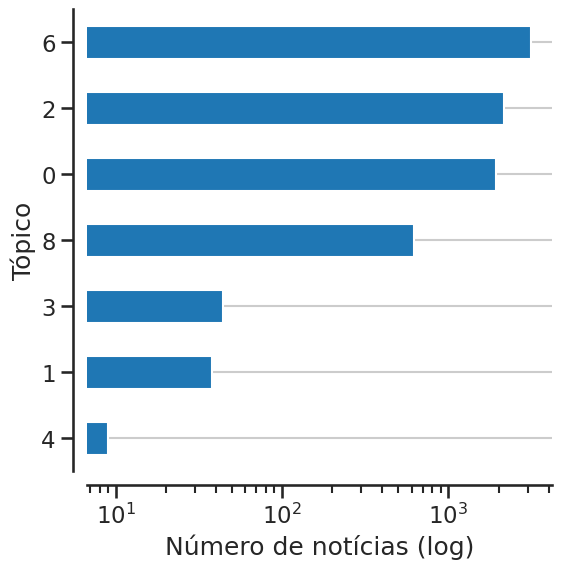

In [64]:
with sns.axes_style("ticks"):
    sns.set_context("talk")
    ax = news_2016['topic'].value_counts().sort_values().plot(kind = 'barh', figsize=(6,6))
    ax.yaxis.grid(True)
    ax.set_ylabel("Tópico")
    ax.set_xlabel("Número de notícias (log)")
    sns.despine(offset = 10)
    ax.set_xscale("log")

## Crie uma nuvem de palavra para cada tópico.

Use as colunas `spacy_lemma` e  `topic` para essa tarefa.

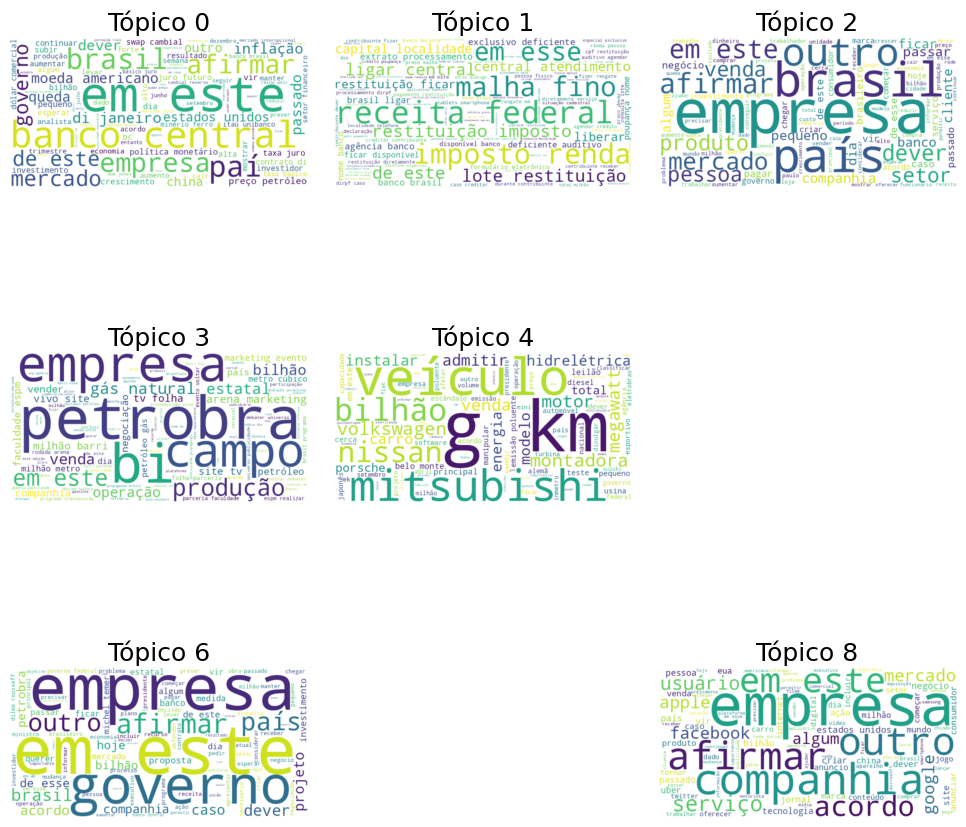

In [67]:
def plot_wordcloud(text:str, ax:plt.Axes) -> plt.Axes:
    """
    Plot the wordcloud for the text/
    Arguments:
        -  text: string to be analised
        -  ax: plt subaxis
    Returns:
     - ax
    """
    # Escreva seu código aqui
    wordcloud = WordCloud(
        background_color='white',
        width=800,
        height=400,
        max_words=100,
        colormap='viridis'
    ).generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    return ax    

def plot_wordcloud_for_a_topic(topic:int, ax:plt.Axes) -> plt.Axes:
    topic_news = news_2016[news_2016['topic'] == topic]
    list_of_words = chain(*topic_news.spacy_lemma.values.tolist())
    string_complete = ' '.join(list_of_words)
    if not string_complete:
        return None
    return plot_wordcloud(string_complete, ax)

fig, axis = plt.subplots(3, 3, figsize=(10, 10))

axis_  = axis.flatten()
for idx, ax in enumerate(axis_):
    ax_ = plot_wordcloud_for_a_topic(idx, ax)
    if ax_ is None:
        plt.delaxes(ax)
        continue
    ax.set_title(f"Tópico {idx}")
fig.tight_layout()

## Crie uma nuvem de entidades para cada tópico.

Use as colunas `spacy_lemma` e  `topic` para essa tarefa.

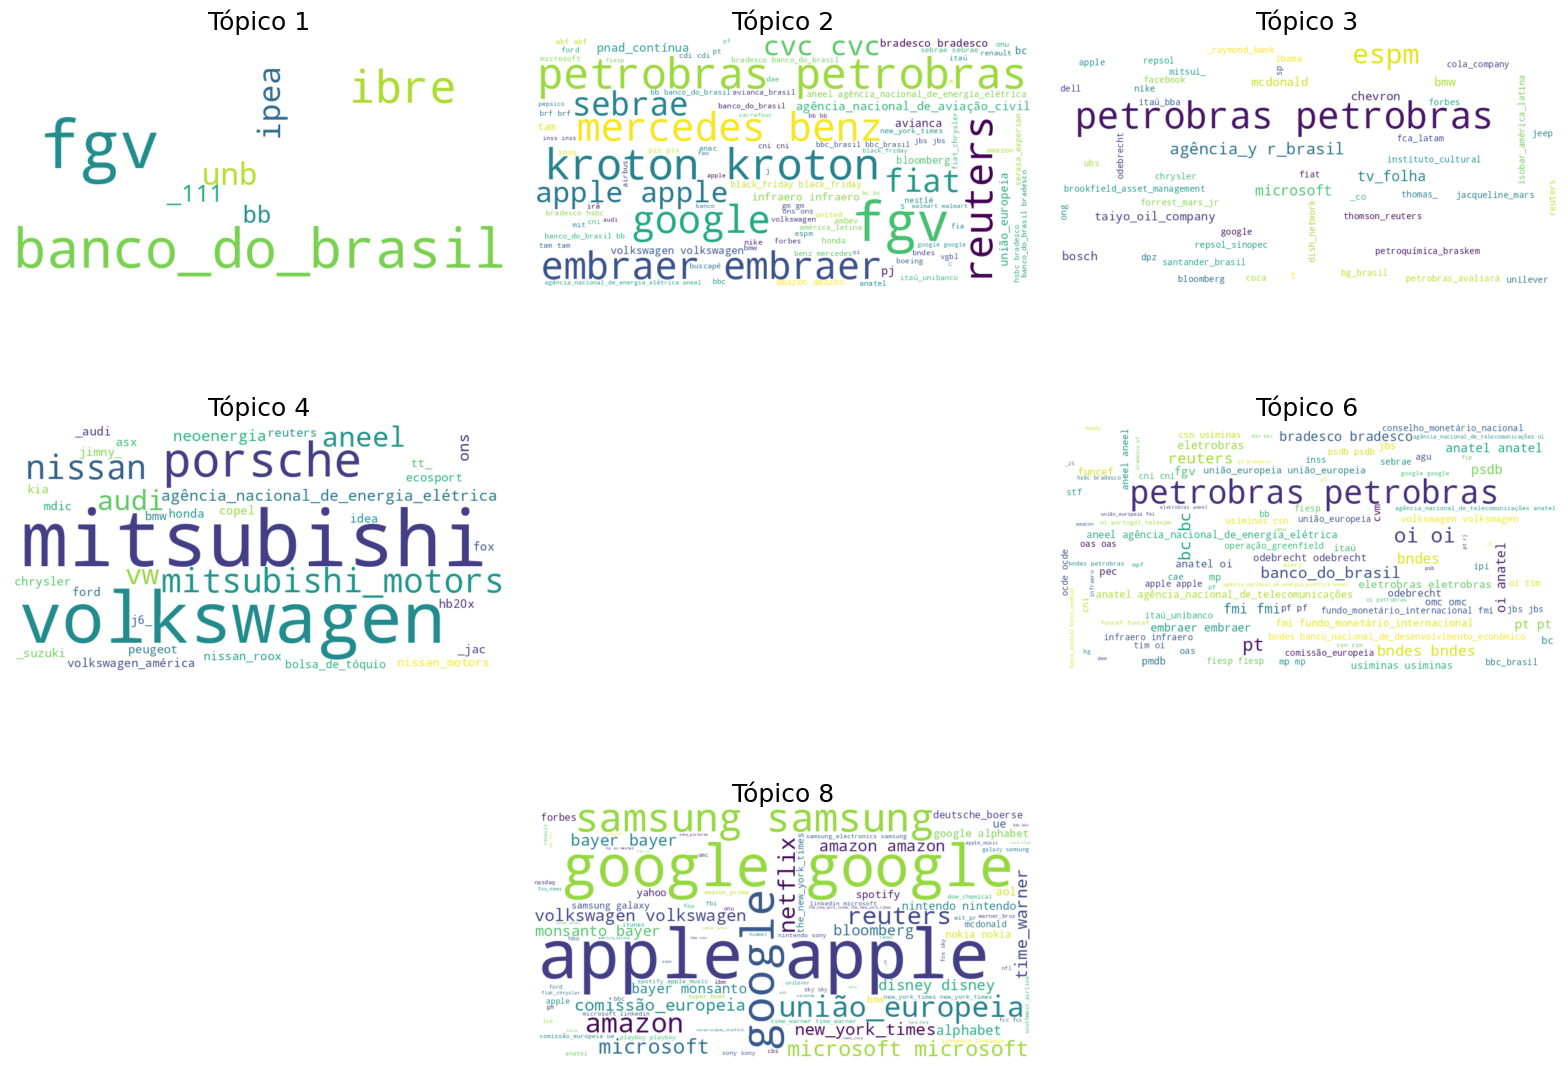

In [66]:
def plot_wordcloud_entities_for_a_topic(topic:int, ax:plt.Axes) -> plt.Axes:
    topic_news = news_2016[news_2016['topic'] == topic]
    list_of_docs = topic_news.spacy_ner.apply(lambda l : [w.replace(" ", "_") for w in l])
    list_of_words = chain(*list_of_docs)
    string_complete = ' '.join(list_of_words)
    if not len(string_complete):
        return None
    return plot_wordcloud(string_complete, ax)

fig, axis = plt.subplots(3, 3, figsize=(16, 12))

axis_  = axis.flatten()
for idx, ax in enumerate(axis_):
    ax_ = plot_wordcloud_entities_for_a_topic(idx + 1, ax)
    if ax_ is None:
        plt.delaxes(ax)
        continue
    ax.set_title(f"Tópico {idx + 1}")
fig.tight_layout()